# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [72]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression

In [2]:
data_path = "credit_risk_dataset.csv"
data = pd.read_csv(data_path)

In [6]:
print(f"Розмір датасету: {data.shape}")
print(f"Кількість клієнтів: {data.shape[0]:,}")
print(f"Кількість ознак: {data.shape[1]}")

Розмір датасету: (32581, 12)
Кількість клієнтів: 32,581
Кількість ознак: 12


In [4]:
data.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [9]:
#Підрахунок кількості кожного класу
class_counts = data['loan_status'].value_counts()

#Підрахунок відсоткового співвідношення
class_percentages = data['loan_status'].value_counts(normalize=True) * 100

print("Кількість записів по класах:")
print(class_counts)
print("\nВідсоткове співвідношення (%):")
print(class_percentages)

Кількість записів по класах:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Відсоткове співвідношення (%):
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64



---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [16]:
#Обчисліть відсоток пропущених значень в колонках. 
missing_data = data.isnull().sum()
missing_percent = (missing_data / len(data)) * 100

missing_percent

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

In [21]:
#За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
# Визначаємо типи колонок
numeric_cols = data.select_dtypes(include=['number']).columns
categorical_cols = data.select_dtypes(include=['str']).columns

# Заповнюємо числові колонки медіаною
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())

# Заповнюємо категоріальні колонки модою
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print(f"Залишилось пропусків після обробки: {data.isnull().sum().sum()}")

Залишилось пропусків після обробки: 0


In [23]:
#Проаналізуйте розподіл числових змінних.
data.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.767994,9589.371106,11.009620,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.087372,6322.086646,3.081611,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Проблемні колонки: person_age та person_emp_length.

person_age: максимальне значення 144 роки. Це біологічно неможливо. Середній вік ($27.7$) та медіана ($26$) вказують на те, що більшість даних коректні, але ці кілька викидів змістять модель.

person_emp_length: максимальне значення 123 роки стажу.

In [25]:
#Видаляємо нереальний вік
data = data[data['person_age'] < 100]

#Видаляємо нереальний стаж
data = data[data['person_emp_length'] < 60]
data.select_dtypes("number").describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32574.000000,3.257400e+04,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000,32574.000000
mean,27.718426,6.587848e+04,4.760576,9588.018051,11.009470,0.218180,0.170202,5.804108
std,6.204987,5.253194e+04,3.981181,6320.249598,3.081664,0.413017,0.106755,4.053873
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.110000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [26]:
#Знайдіть та обробіть викиди в колонці person_income з допомогою Interquartile range.

# Обчислюємо перший та третій квартилі
Q1 = data['person_income'].quantile(0.25)
Q3 = data['person_income'].quantile(0.75)

# Обчислюємо міжквартильний розмах
IQR = Q3 - Q1

# Визначаємо межі
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Нижня межа: {lower_bound}")
print(f"Верхня межа: {upper_bound}")

Нижня межа: -22550.0
Верхня межа: 140250.0


In [27]:
# Рахуємо кількість викидів
outliers = data[(data['person_income'] < lower_bound) | (data['person_income'] > upper_bound)]
print(f"Кількість виявлених викидів: {len(outliers)}")

# Фільтруємо дані
data_cleaned = data[(data['person_income'] >= lower_bound) & (data['person_income'] <= upper_bound)]

print(f"Розмір датасету до очищення: {data.shape[0]}")
print(f"Розмір датасету після очищення: {data_cleaned.shape[0]}")

Кількість виявлених викидів: 1480
Розмір датасету до очищення: 32574
Розмір датасету після очищення: 31094


In [30]:
categorical_columns = data_cleaned.select_dtypes(include=['str']).columns
unique_counts = data_cleaned[categorical_columns].nunique()

print("Кількість унікальних значень у категоріальних колонках:")
print(unique_counts)

Кількість унікальних значень у категоріальних колонках:
person_home_ownership        4
loan_intent                  6
loan_grade                   7
cb_person_default_on_file    2
dtype: int64


In [29]:
#Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них
categorical_cols = data.select_dtypes(include=['str']).columns

for col in categorical_cols:
    print(f"--- Розподіл для {col} ---")
    print(data[col].value_counts())
    print("\n")

--- Розподіл для person_home_ownership ---
person_home_ownership
RENT        16442
MORTGAGE    13441
OWN          2584
OTHER         107
Name: count, dtype: int64


--- Розподіл для loan_intent ---
loan_intent
EDUCATION            6451
MEDICAL              6071
VENTURE              5716
PERSONAL             5519
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


--- Розподіл для loan_grade ---
loan_grade
A    10776
B    10448
C     6456
D     3625
E      964
F      241
G       64
Name: count, dtype: int64


--- Розподіл для cb_person_default_on_file ---
cb_person_default_on_file
N    26830
Y     5744
Name: count, dtype: int64




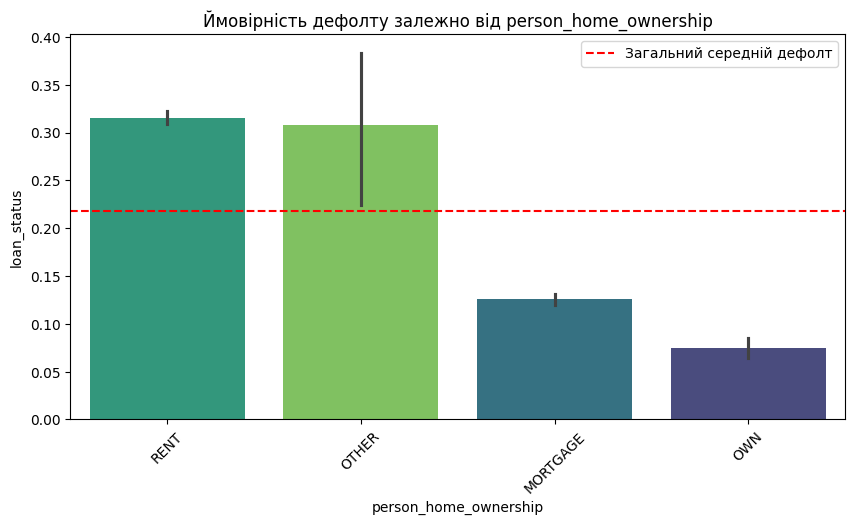

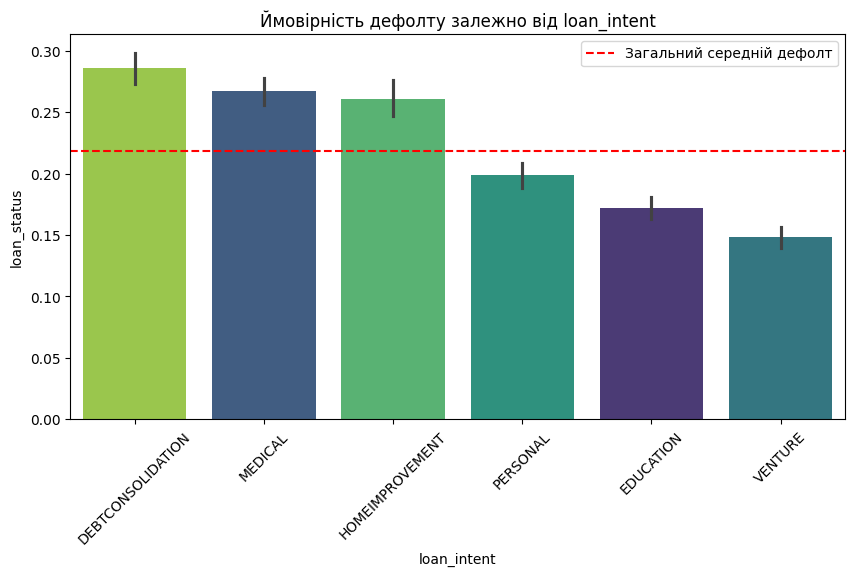

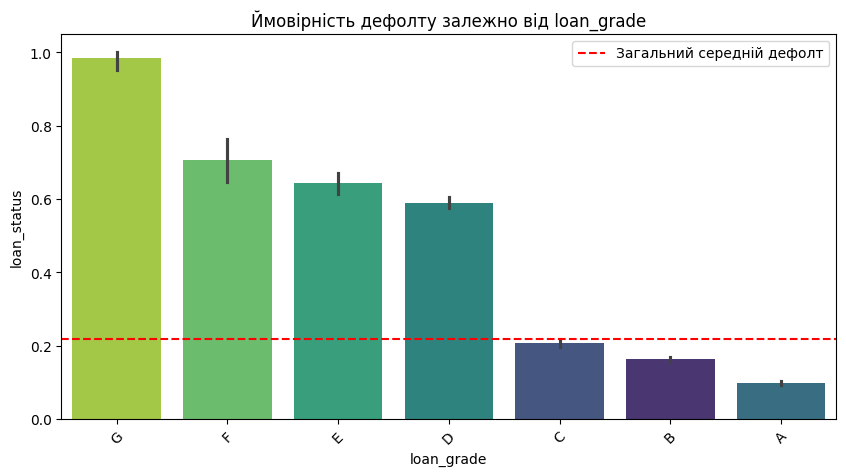

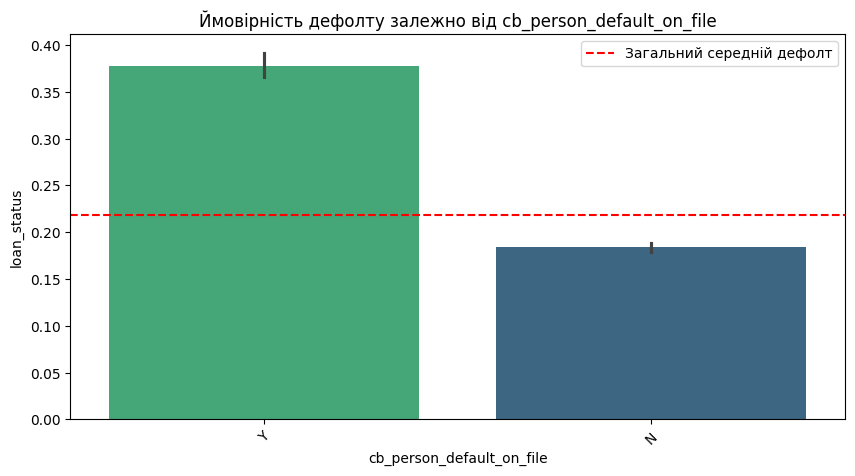

In [35]:
#Візуалізуйте взаємозв'язок ознак з цільовою змінною.
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    
    # Розрахунок частки дефолтів
    order = data.groupby(col)['loan_status'].mean().sort_values(ascending=False).index
    
    sns.barplot(x=col, y='loan_status', data=data, order=order, hue=col, palette='viridis',legend=False)
    plt.axhline(data['loan_status'].mean(), color='red', linestyle='--', label='Загальний середній дефолт')
    plt.title(f'Ймовірність дефолту залежно від {col}')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

person_home_ownership

Люди, які орендують житло (RENT), мають вищий ризик дефолту порівняно з тими, хто має іпотеку (MORTGAGE) або власне житло.

loan_intent

Кредити на консолідацію боргу (Debt consolidation), медицину (Medical) та покращення житла (Home Improvement) мають більше шансів на дефолт.

loan_grade

Чим гірша категорія (від A до G), тим стрімкіше зростає ймовірність дефолту.

cb_person_default_on_file

Клієнти, які вже мали дефолт в кредитній історії (Y), зазвичай мають значно вищий шанс повторного дефолту.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



In [39]:
#Побудуйте матрицю кореляцій для числових змінних.
metrics_data = data_cleaned.select_dtypes(include=['number']).corr()

correlation_matrix = metrics_data.corr()
correlation_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,-0.018056,0.087868,-0.507982,-0.370013,-0.403318,-0.420803,0.987414
person_income,-0.018056,1.000000,0.282619,0.207289,-0.347178,-0.714179,-0.602171,-0.045822
person_emp_length,0.087868,0.282619,1.000000,-0.221925,-0.469942,-0.523685,-0.412574,0.062372
loan_amnt,-0.507982,0.207289,-0.221925,1.000000,-0.116616,-0.021175,0.647014,-0.509411
loan_int_rate,-0.370013,-0.347178,-0.469942,-0.116616,1.000000,0.461546,0.126331,-0.353227
loan_status,-0.403318,-0.714179,-0.523685,-0.021175,0.461546,1.000000,0.549925,-0.380769
loan_percent_income,-0.420803,-0.602171,-0.412574,0.647014,0.126331,0.549925,1.000000,-0.400502
cb_person_cred_hist_length,0.987414,-0.045822,0.062372,-0.509411,-0.353227,-0.380769,-0.400502,1.000000


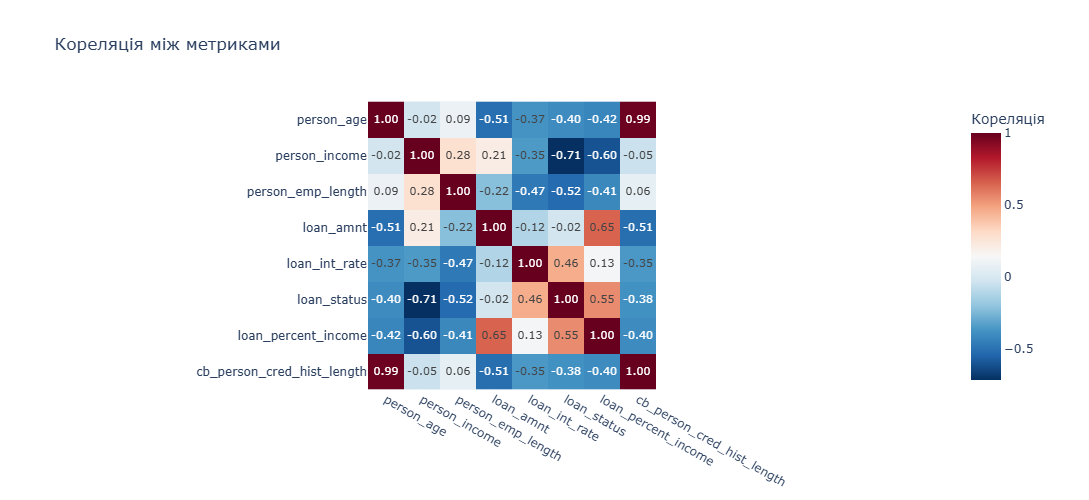

In [38]:
fig = px.imshow(
    correlation_matrix,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    title='Кореляція між метриками',
    labels=dict(color="Кореляція")
)
fig.update_layout(height=500)
fig.show()

In [42]:
#Закодуйте категоріальні змінні.
data_encoded = pd.get_dummies(data_cleaned, drop_first=True)

print(f"Кількість колонок до кодування: {data_cleaned.shape[1]}")
print(f"Кількість колонок після кодування: {data_encoded.shape[1]}")

Кількість колонок до кодування: 12
Кількість колонок після кодування: 23


In [44]:
print(data_encoded.columns.tolist())

['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']


In [45]:
#Видаляю колонку person_age
data_encoded = data_encoded.drop('person_age', axis=1)


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [47]:
#Розділіть дані на X та y
X = data_encoded.drop('loan_status', axis=1)
y = data_encoded['loan_status']

print(f"Фінальна кількість ознак для навчання: {X.shape[1]}")

Фінальна кількість ознак для навчання: 21


In [49]:
#Поділіть на навчальну та тестову вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Розмір навчальної вибірки: {X_train.shape[0]} записів")
print(f"Розмір тестової вибірки: {X_test.shape[0]} записів")

print("\nЧастка дефолтів у навчальній вибірці:", y_train.mean().round(4))
print("Частка дефолтів у тестовій вибірці:", y_test.mean().round(4))

Розмір навчальної вибірки: 24875 записів
Розмір тестової вибірки: 6219 записів

Частка дефолтів у навчальній вибірці: 0.2239
Частка дефолтів у тестовій вибірці: 0.2238


In [50]:
#Застосуйте масштабування
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Середнє після масштабування: {X_train_scaled.mean(axis=0)[0].round(2)}")
print(f"Стандартне відхилення: {X_train_scaled.std(axis=0)[0].round(2)}")

Середнє після масштабування: -0.0
Стандартне відхилення: 1.0


In [52]:
#Навчіть модель логістичної регресії
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Модель навчена!")

Модель навчена!


In [53]:
#Зробіть прогнози на тренувальній та тестовій вибірках.
# Прогнози для ТЕСТОВОЇ вибірки
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)

# Прогнози для ТРЕНУВАЛЬНОЇ вибірки
y_train_pred = model.predict(X_train_scaled)
y_train_proba = model.predict_proba(X_train_scaled)

print("Прогнози успішно сформовані для обох вибірок.")

Прогнози успішно сформовані для обох вибірок.


In [54]:
# Приклад прогнозів для перших 5 клієнтів
sample_predictions = pd.DataFrame({
    'Реальний дефолт': y_test.values[:5],
    'Прогноз': y_test_pred[:5],
    'Ймовірність виплати': y_test_proba[:5, 0].round(3),
    'Ймовірність дефолту': y_test_proba[:5, 1].round(3)
})
print(sample_predictions)

   Реальний дефолт  Прогноз  Ймовірність виплати  Ймовірність дефолту
0                0        0                0.573                0.427
1                0        0                0.947                0.053
2                0        0                0.837                0.163
3                0        0                0.930                0.070
4                1        0                0.509                0.491



---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


<Figure size 800x600 with 0 Axes>

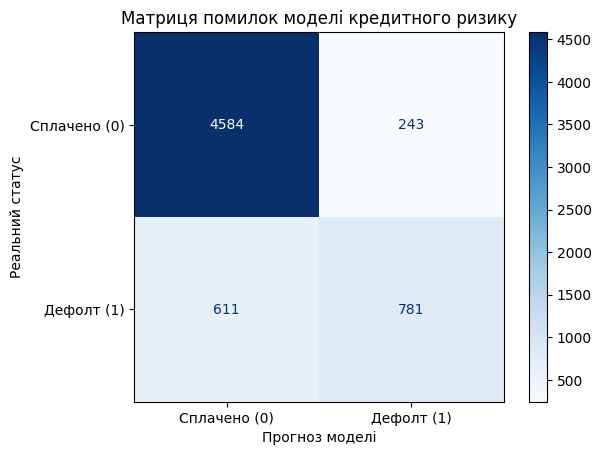

In [56]:
#Побудуйте confusion matrix.
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено (0)', 'Дефолт (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Матриця помилок моделі кредитного ризику')
plt.xlabel('Прогноз моделі')
plt.ylabel('Реальний статус')
plt.show()

True Negatives (4584): Це клієнти, яких модель правильно визначила як надійних.

False Positives (243): Модель назвала їх ризиковими, хоча вони б повернули гроші. Банк втратив 243 клієнти.

False Negatives (611): Це зона високого ризику. Модель помилково вважала 611 осіб надійними, хоча вони пішли в дефолт. Банк поніс збитки.

True Positives (781): Модель успішно виявила 781 дефолти і врятувала гроші банку.

In [59]:
#Обчисліть основні метрики (accuracy, precision, recall, f1).

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.863
Precision (Влучність):  0.763
Recall (Повнота):       0.561
F1-score:               0.647


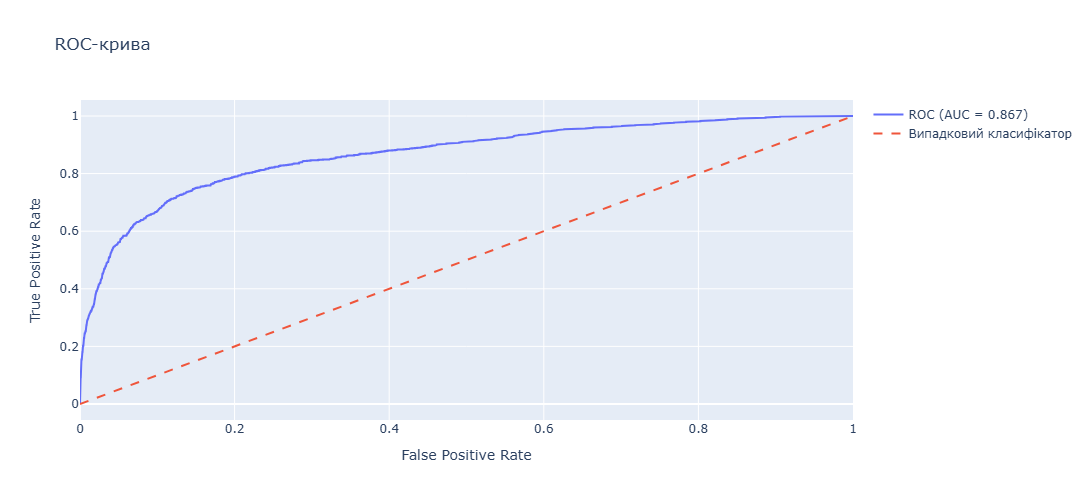

In [61]:
#Побудуйте ROC-криву та обчисліть AUC
# Обчислюємо ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba[:, 1])
auc = roc_auc_score(y_test, y_test_proba[:, 1])

# Візуалізація
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC = {auc:.3f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', line=dict(dash='dash'),
                        name='Випадковий класифікатор'))
fig.update_layout(
    title='ROC-крива',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=500
)
fig.show()

AUC = 0.867 модель має високу здатність розрізняти майбутніх банкрутів та надійних позичальників.

In [62]:
#Проаналізуйте важливість ознак.
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'abs_coefficient': np.abs(model.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

feature_importance

,feature,coefficient,abs_coefficient
4,loan_percent_income,1.299366,1.299366
16,loan_grade_D,0.769737,0.769737
2,loan_amnt,-0.510300,0.510300
17,loan_grade_E,0.459598,0.459598
7,person_home_ownership_OWN,-0.445114,0.445114
8,person_home_ownership_RENT,0.417216,0.417216
13,loan_intent_VENTURE,-0.409872,0.409872
9,loan_intent_EDUCATION,-0.329822,0.329822
19,loan_grade_G,0.280100,0.280100
18,loan_grade_F,0.249384,0.249384


loan_percent_income (1.299) найбільше впливає на дефолт. Модель зрозуміла, що якщо кредит забирає велику частку доходу, ризик дефолту зростає експоненціально. 

Рейтинги кредиту loan_grade_D (0.769) та loan_grade_E (0.459) мають високі позитивні значення. Це означає, що як тільки клієнт потрапляє в ці категорії, ймовірність дефолту різко зростає.

loan_amnt (-0.510): більша сума кредиту дещо знижує ризик дефолту. Це може бути пов'язано з тим, що великі суми банк видає лише дуже перевіреним клієнтам.

person_home_ownership_OWN (-0.445) - ласне житло суттєво знижує ризик.



**Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.**

AUC має високий показник. Модель у 85% випадків поставить вищу ймовірність дефолту реальному дефолтеру, ніж надійному клієнту. 

Recall для дефолту становить 56% - модель пропускає близько 44% потенційних дефолтів. У реальних умовах банку це може означати високі фінансові втрати.

Precision для дефолту - 76%. Модель має досить високу точність.


Найвпливовіші ознаки 

Аналіз коефіцієнтів показав, що модель приймає рішення на основі таких економічних факторів:

Найбільший ризик — loan_percent_income: чим більшу частину доходу займає платіж, тим вища ймовірність, що клієнт не витримає фінансового тиску.

Рейтинг кредиту (loan_grade) D та E є потужними предикторами дефолту. Модель використовує внутрішню банківську оцінку ризиків.

Власне житло значно підвищує довіру моделі до клієнта, тоді як оренда — навпаки, додає балів до ймовірності дефолту.




---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



In [70]:
# Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів)
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
metrics_by_threshold = []

for threshold in thresholds:
    y_pred_custom = (y_test_proba[:, 1] >= threshold).astype(int)

    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

df_thresholds = pd.DataFrame(metrics_by_threshold)
print(df_thresholds.round(3))

   threshold  precision  recall     f1
0        0.2      0.520   0.798  0.630
1        0.3      0.620   0.723  0.668
2        0.4      0.692   0.643  0.667
3        0.5      0.763   0.561  0.647
4        0.6      0.812   0.467  0.593
5        0.7      0.849   0.358  0.504
6        0.8      0.907   0.259  0.402


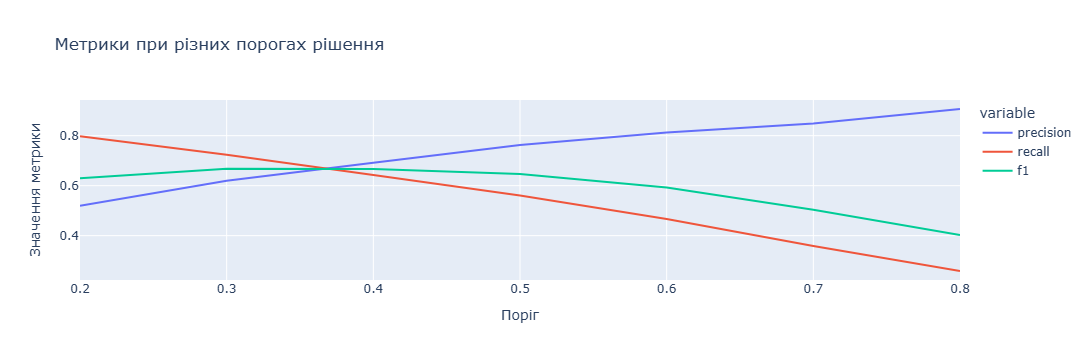

In [71]:
# Візуалізація
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

Найоптимальнішим значенням порогу є 0.35. У цій точці Precision та Recall зрівнюються, тут же ми бачимо пік метрики F1.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


In [73]:
#Альтернативні моделі
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_pred_proba)
    })

results_df = pd.DataFrame(results).round(3)
print(results_df)

                 Model  Accuracy  Precision  Recall     F1    AUC
0  Logistic Regression     0.863      0.763   0.561  0.647  0.867
1        Decision Tree     0.904      0.960   0.596  0.735  0.869
2        Random Forest     0.929      0.956   0.714  0.817  0.923


Для впровадження в банківську систему найкраще підходить Random Forest Classifier, адже він має найвищі показники по всім параметрам.